In [1]:
try:
  %matplotlib ipympl
except:
  pass


In [2]:
import os, sys, subprocess

REPO = "https://github.com/jongmoonha/Train_fault_simulation.git"
DIR  = "Train_fault_simulation"

try:
    import google.colab  # Colab 전용 모듈
    if not os.path.isdir(DIR):
        subprocess.run(["git","clone",REPO], check=True)
    print('We are in Google Colab environment.')
    os.chdir('/content/'+DIR)
    print('Current working directory:', os.getcwd())

except ImportError:
    print('We are in a local environment, not Google Colab.')
    pass

We are in a local environment, not Google Colab.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.stats import kurtosis

from utils.utils_processing import fft_simple, filtering, get_fault_frequency, fault_repeat_uncertainty, generate_unit_impulse_response, envelope_spectrum_band
from utils.utils_plot import plot_raw, plot_spectrum, five_harmonics
from utils import kurtogram as kg

%matplotlib widgetmal Signal (or Import the Signal)

# Configuration for the Generation

In [4]:
config = {
    'condition': 'O',      # 'I' | 'O' | 'B'
    'fs': 51200,
    'T' : 1,
    'segments': 1,
    'speed_rpm': 1350,     # shaft speed
    'Bd': 7.6, 'Nb': 8, 'd1': 20, 'd2': 47, 'a': 0,
    'beta_range': (700, 710),
    'fn_range': (12000, 12010),
    'fault_amp': 0.003,
    'A_normal': 0.0005,
    'nlevel' : 7,
    'nlevel_seg' : 4,
}

# Normal Signal Generation

In [5]:
# Import
# Generation
rng = np.random.default_rng(0)
T = config['T']
fs = config['fs']
A_normal = config['A_normal']

N = int(fs*T)
t = np.arange(N)/fs
x_normal = A_normal*np.sin(2*np.pi*config['speed_rpm']/60*t) + 0.00005*rng.standard_normal(N)

# Signal Info
print('Signal Info:')
print(f'  Sampling Frequency: {fs} Hz')
print(f'  Signal Length: {N} samples ({T:.3f} sec)')

Signal Info:
  Sampling Frequency: 51200 Hz
  Signal Length: 51200 samples (1.000 sec)


# Fault Signal Generation

In [6]:
# Fault Characteristic Frequency
fault_freq, FTF, FCF, unit = get_fault_frequency(config)
fr = config['speed_rpm']/60
print(f'Rotational frequency: {fr:.1f} Hz')
print(f'freq_w_fault_featurey: {fault_freq:.1f} Hz')

# Unit impulse response
unit_fault_feature, Beta, Fn = generate_unit_impulse_response(t, config['beta_range'], config['fn_range'], rng)

# Synthesized Faulty Signal
x_fault_feature = fault_repeat_uncertainty(unit_fault_feature, FCF, fr, t, fs, FTF, config['condition']) * config['fault_amp']
x_fault_signal = x_normal + x_fault_feature

Rotational frequency: 22.5 Hz
freq_w_fault_featurey: 69.6 Hz


Text(0.5, 1.0, 'Envelope Spectrum of Simulated Fault Feature')

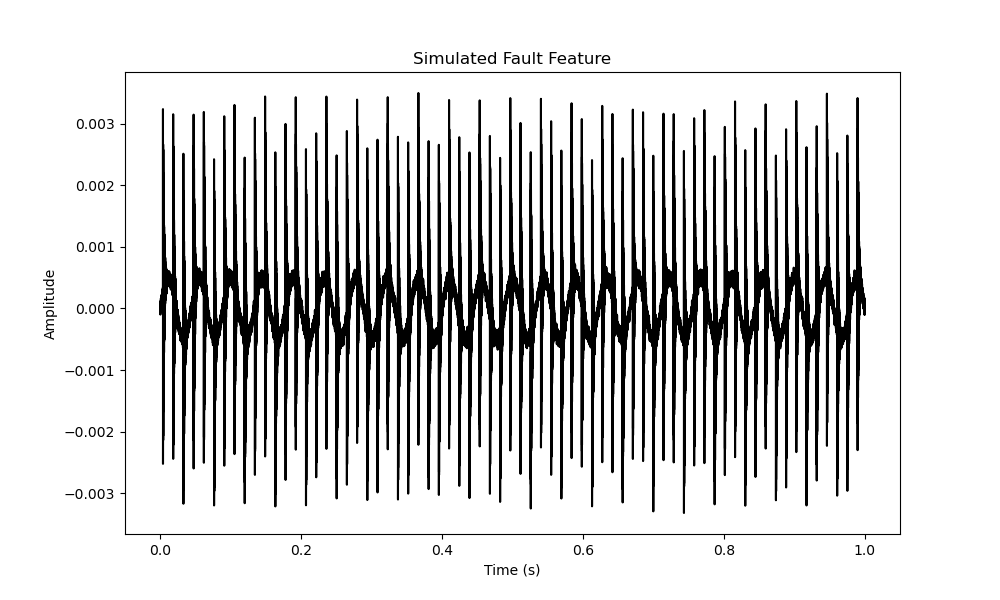

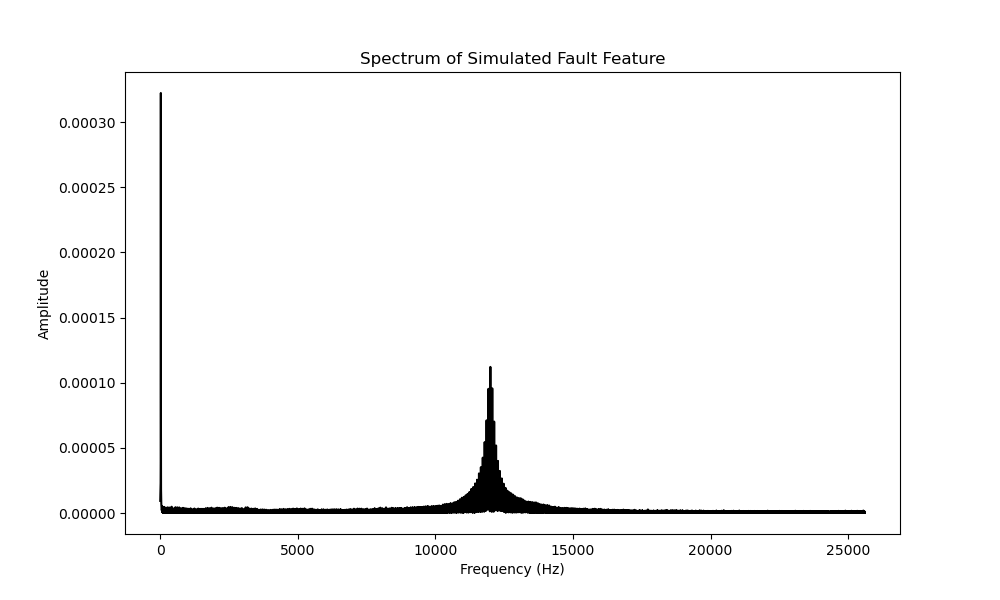

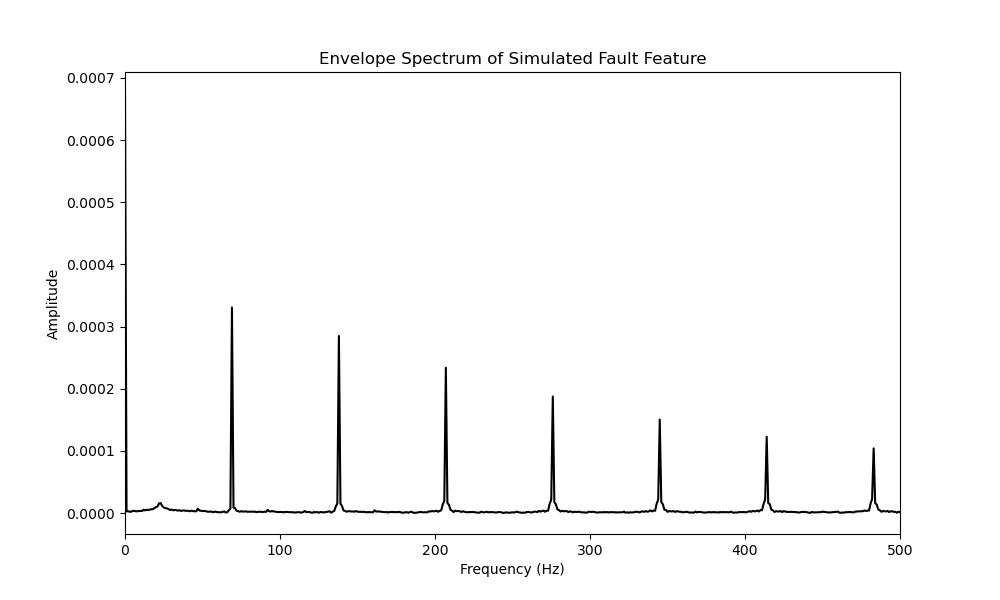

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(t, x_fault_signal, 'k')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Simulated Fault Feature')

f, A = fft_simple(x_fault_signal, fs)
plt.figure(figsize=(10, 6))
plt.plot(f, A, 'k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Spectrum of Simulated Fault Feature')

f_env, A_env = fft_simple(abs(hilbert(x_fault_signal)), fs)
plt.figure(figsize=(10, 6))
plt.plot(f_env, A_env, 'k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 500)
plt.title('Envelope Spectrum of Simulated Fault Feature')

# Normal + Feature

Text(0.5, 1.0, 'Envelope Spectrum of Simulated Fault Feature')

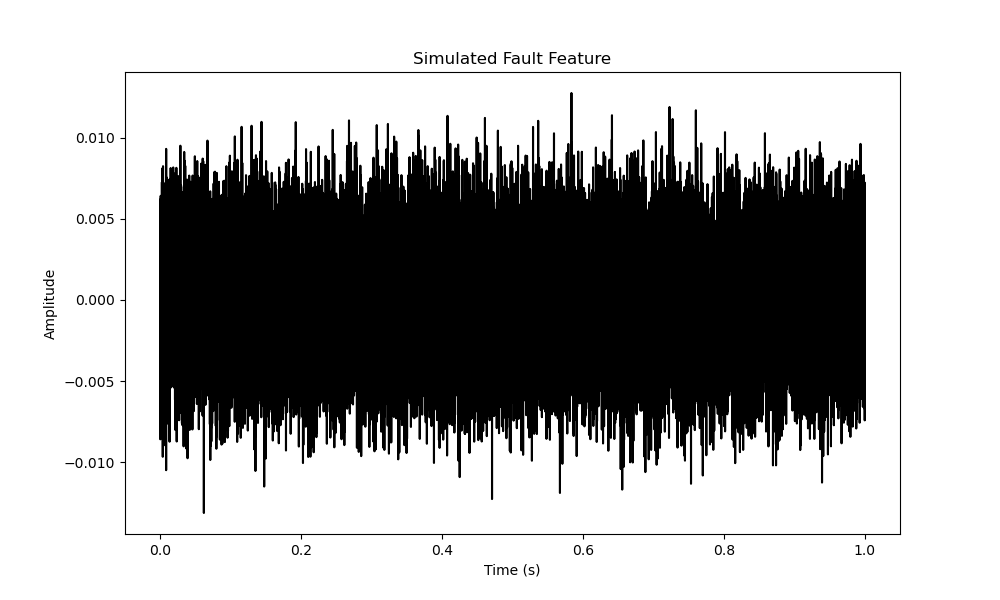

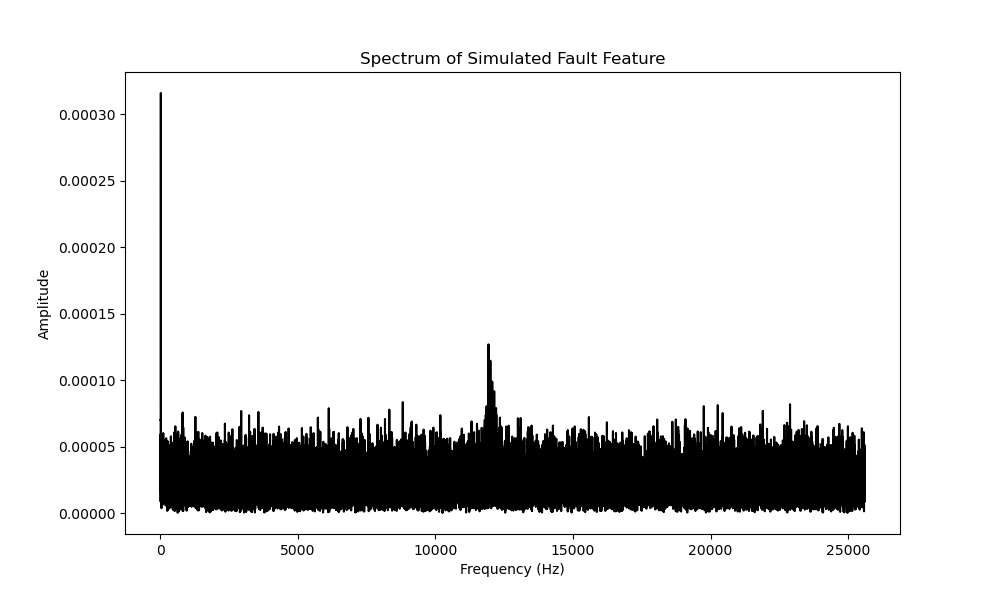

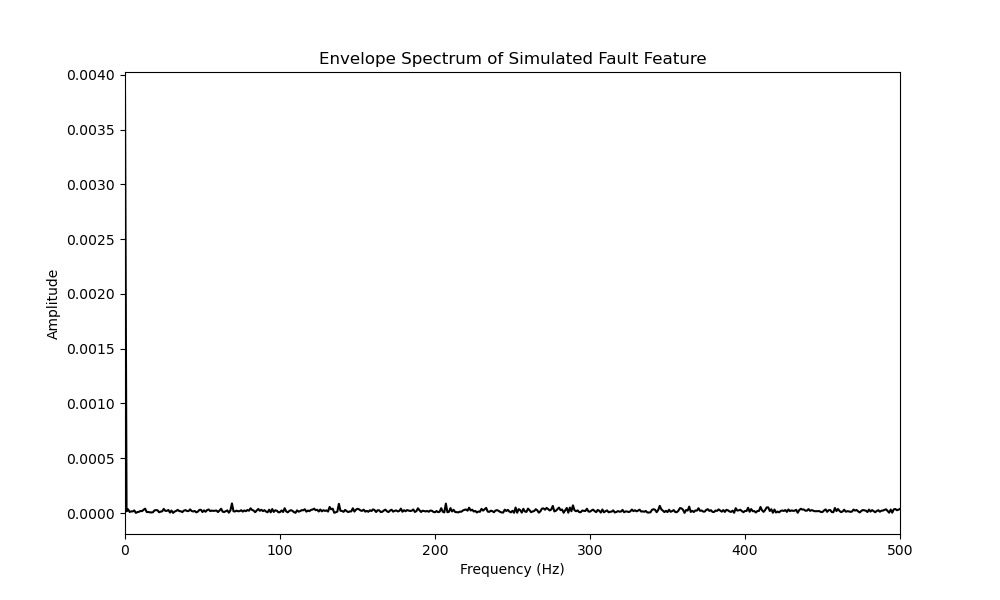

In [8]:
rnd_a = 0.003
plt.figure(figsize=(10, 6))
plt.plot(t, x_fault_signal + rng.standard_normal(N) * rnd_a, 'k')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Simulated Fault Feature')

f, A = fft_simple(x_fault_signal + rng.standard_normal(N) * rnd_a, fs)
plt.figure(figsize=(10, 6))
plt.plot(f, A, 'k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Spectrum of Simulated Fault Feature')

f_env, A_env = fft_simple(abs(hilbert(x_fault_signal + rng.standard_normal(N) * rnd_a)), fs)
plt.figure(figsize=(10, 6))
plt.plot(f_env, A_env, 'k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 500)
plt.title('Envelope Spectrum of Simulated Fault Feature')

# Normal + Feature -> Band-pass Filter (Known band range)

Text(0.5, 1.0, 'Envelope Spectrum of Band-pass Filtered Signal (1150-1250 Hz)')

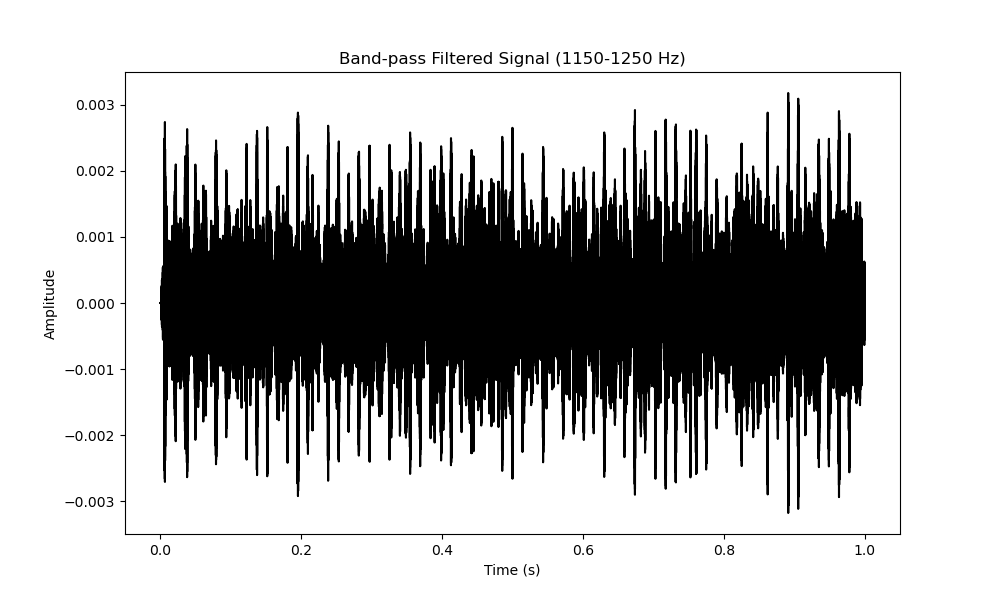

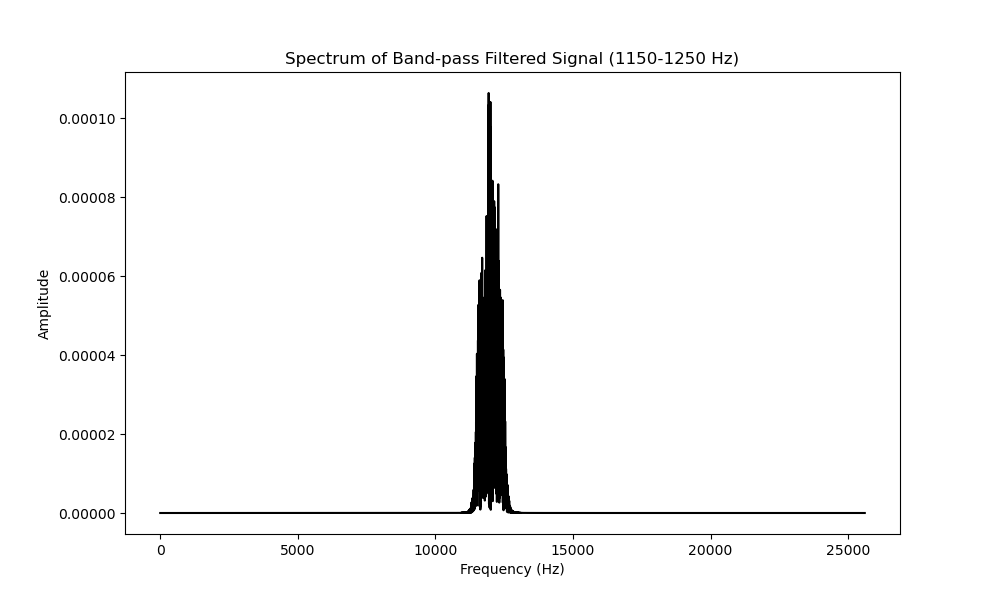

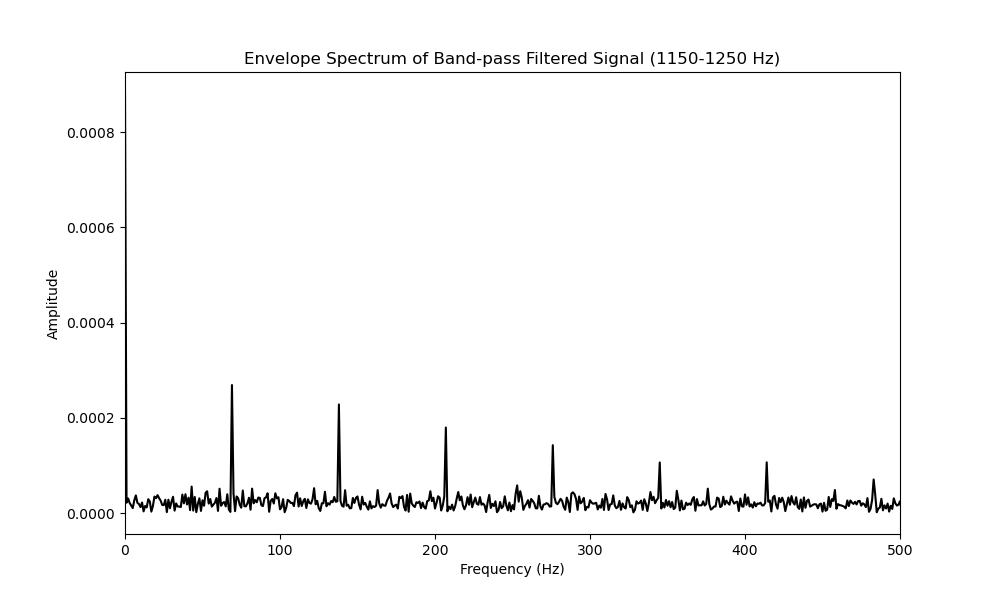

In [9]:
# Band-pass filter
x_fault_signal_filt = filtering(x_fault_signal+ rng.standard_normal(N) * rnd_a, fs, np.array([11500, 12500]), ftype='bandpass')

plt.figure(figsize=(10, 6))
plt.plot(t, x_fault_signal_filt, 'k')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Band-pass Filtered Signal (1150-1250 Hz)')

f, A = fft_simple(x_fault_signal_filt, fs)
plt.figure(figsize=(10, 6))
plt.plot(f, A, 'k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Spectrum of Band-pass Filtered Signal (1150-1250 Hz)')

f_env, A_env = fft_simple(abs(hilbert(x_fault_signal_filt)), fs)
plt.figure(figsize=(10, 6))
plt.plot(f_env, A_env, 'k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 500)
plt.title('Envelope Spectrum of Band-pass Filtered Signal (1150-1250 Hz)')

# Kurtogram

[12133.33333333 12933.33333333]


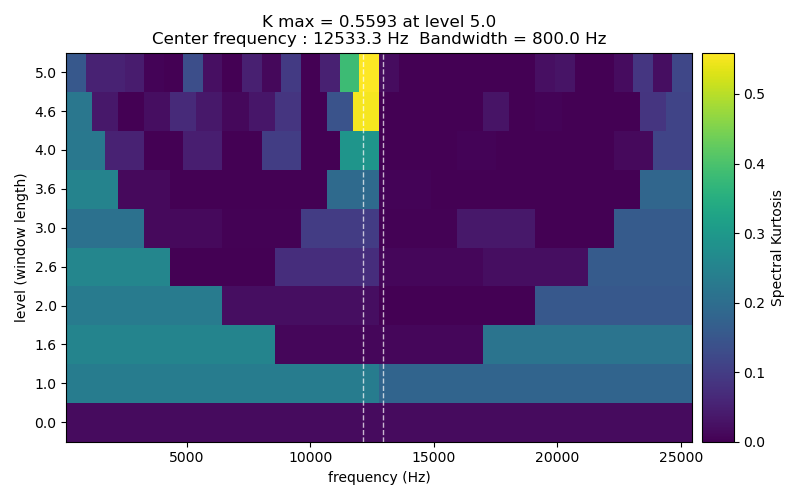

In [10]:
Kwav, Level_w, freq_w, c_norm, maxK, bw, lvl, Wn = kg.fast_kurtogram(x_fault_signal+ rng.standard_normal(N) * rnd_a, fs, nlevel=5)
print(Wn)
kg.plot_kurtogram(Kwav, Level_w, maxK, bw, lvl, fs, Wn)
